In [5]:
import os
import nibabel as nib
import numpy as np
from pathlib import Path

# Define the base folder path
base_folder = r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_voxel-label"

# Iterate over all subdirectories
for subject_dir in sorted(os.listdir(base_folder)):
    subject_path = os.path.join(base_folder, subject_dir)
    
    if not os.path.isdir(subject_path):
        continue
    
    # Load the image
    image_file = os.path.join(subject_path, "image.nii.gz")
    if not os.path.exists(image_file):
        continue
    
    img = nib.load(image_file)
    
    # Check all label_annot files (1-4)
    mismatches = []
    for annot_num in range(1, 5):
        label_file = os.path.join(subject_path, f"label_annot_{annot_num}.nii.gz")
        
        if not os.path.exists(label_file):
            continue
        
        mask = nib.load(label_file)
        
        # Check affine match
        if not np.allclose(img.affine, mask.affine, atol=1e-3):
            mismatches.append(f"label_annot_{annot_num}.nii.gz")
    
    # Report results
    if mismatches:
        print(f"⚠️  {subject_dir}: Affine mismatch in {', '.join(mismatches)}")


CT shape: (512, 512, 31) | dtype: float64
Mask shape: (512, 512, 31) | dtype: float64
Affine match: True

Annotation label classes (non-zero): [3, 4]


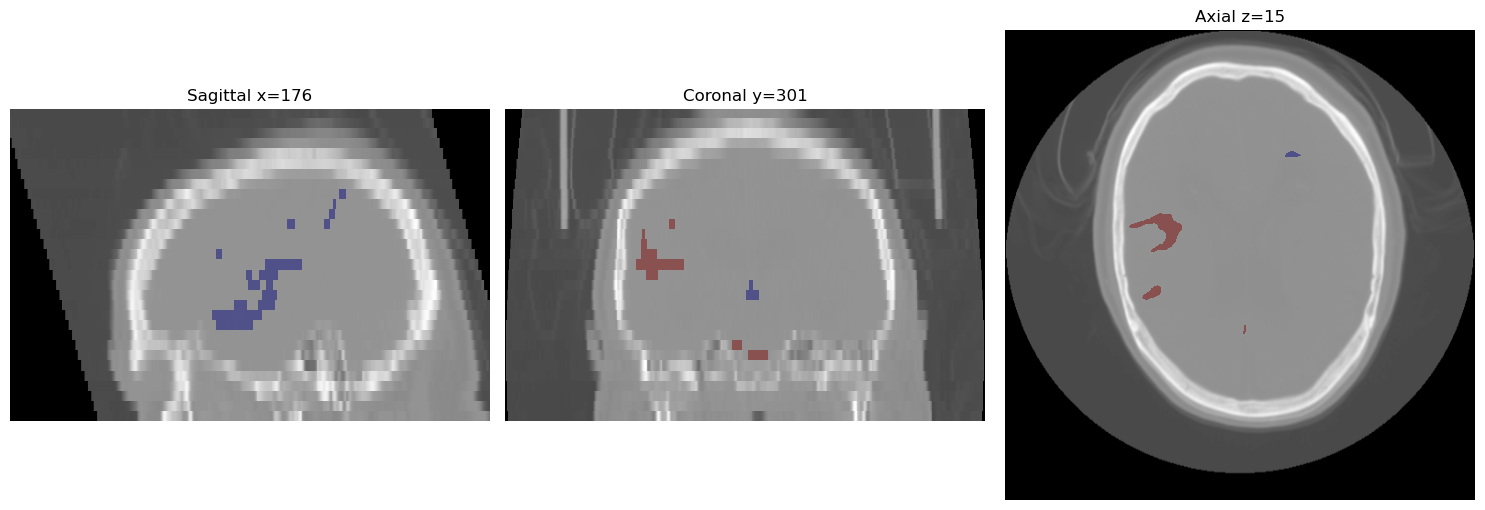


Consensus label classes (non-zero): [3, 4]

Consensus shape: (512, 512, 31) | dtype: float64
Consensus affine match: True


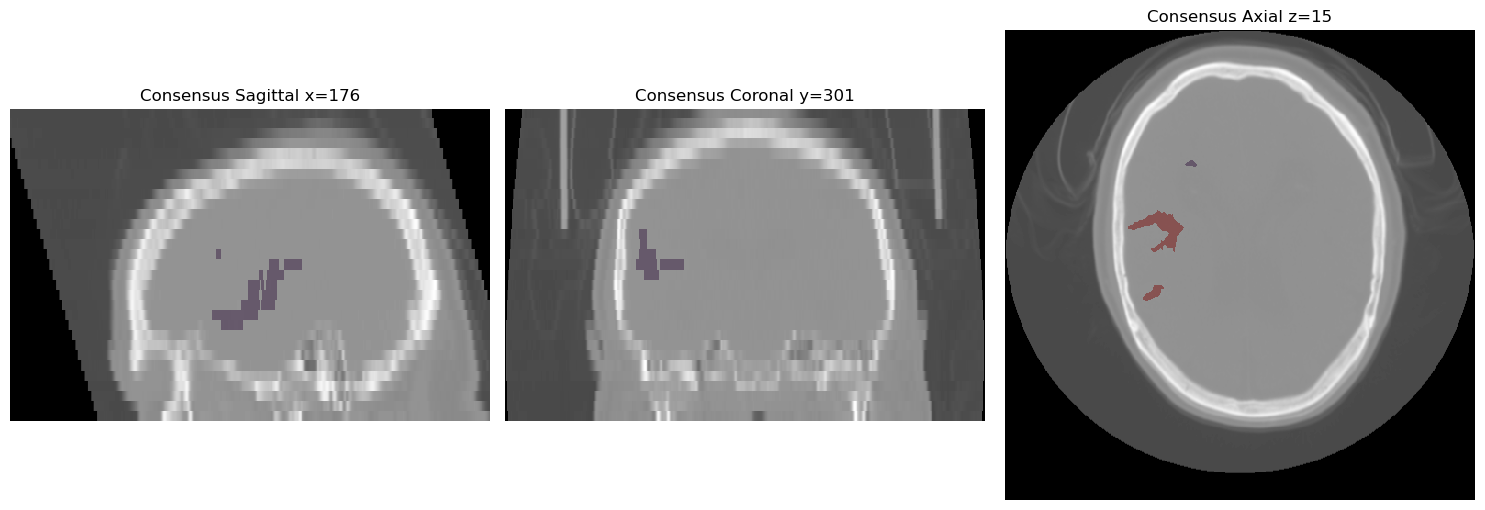

In [13]:
import matplotlib.pyplot as plt
import os

# Load voxel arrays from existing NIfTI objects
base_folder = r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_voxel-label"
ID = 'ID_0c6b97a9_ID_6011bb9ce8'
img_path = os.path.join(base_folder, ID, "image.nii.gz")
mask_path = os.path.join(base_folder, ID, "label_annot_2.nii.gz")

img = nib.load(img_path)
mask = nib.load(mask_path)
ct = img.get_fdata()
lbl = mask.get_fdata()

print("CT shape:", ct.shape, "| dtype:", ct.dtype)
print("Mask shape:", lbl.shape, "| dtype:", lbl.dtype)
print("Affine match:", np.allclose(img.affine, mask.affine, atol=1e-3))

# Print label classes present in this annotation
annotation_labels = np.unique(lbl)
annotation_labels = annotation_labels[annotation_labels > 0]
print("\nAnnotation label classes (non-zero):", annotation_labels.astype(int).tolist())


# Optional class names (edit if your dataset uses a different mapping)
class_names = {
    1: "Intraparenchymal",
    2: "Intraventricular",
    3: "Subarachnoid",
    4: "Subdural",
    5: "Epidural",
}



# Pick slices with the most labeled voxels for clearer visualization
x_idx = int(np.argmax((lbl > 0).sum(axis=(1, 2))))  # sagittal
y_idx = int(np.argmax((lbl > 0).sum(axis=(0, 2))))  # coronal
z_idx = int(np.argmax((lbl > 0).sum(axis=(0, 1))))  # axial

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Use physical voxel spacing to avoid squeezed views
vx, vy, vz = nib.affines.voxel_sizes(img.affine)

# Sagittal (YZ plane)
sag_ct = ct[x_idx, :, :].T
sag_lbl = lbl[x_idx, :, :].T
axes[0].imshow(sag_ct, cmap="gray", origin="lower", interpolation="nearest")
axes[0].imshow(
    np.ma.masked_where(sag_lbl == 0, sag_lbl),
    cmap="jet", alpha=0.45, origin="lower", interpolation="nearest"
)
axes[0].set_aspect(vz / vy)  # y-axis=z spacing, x-axis=y spacing
axes[0].set_title(f"Sagittal x={x_idx}")
axes[0].axis("off")

# Coronal (XZ plane)
cor_ct = ct[:, y_idx, :].T
cor_lbl = lbl[:, y_idx, :].T
axes[1].imshow(cor_ct, cmap="gray", origin="lower", interpolation="nearest")
axes[1].imshow(
    np.ma.masked_where(cor_lbl == 0, cor_lbl),
    cmap="jet", alpha=0.45, origin="lower", interpolation="nearest"
)
axes[1].set_aspect(vz / vx)  # y-axis=z spacing, x-axis=x spacing
axes[1].set_title(f"Coronal y={y_idx}")
axes[1].axis("off")

# Axial
axes[2].imshow(ct[:, :, z_idx].T, cmap="gray", origin="lower")
axes[2].imshow(np.ma.masked_where(lbl[:, :, z_idx].T == 0, lbl[:, :, z_idx].T),
               cmap="jet", alpha=0.45, origin="lower")
axes[2].set_title(f"Axial z={z_idx}")
axes[2].axis("off")

plt.tight_layout()
plt.show()

# Plot consensus annotation (STAPLE) for the same subject
consensus_path = os.path.join(
    os.path.dirname(img.get_filename()),
    "label_consensus_staple.nii.gz"
)

if os.path.exists(consensus_path):
    consensus_nib = nib.load(consensus_path)
    lbl_cons = consensus_nib.get_fdata()

    # Print labels in consensus
    consensus_labels = np.unique(lbl_cons)
    consensus_labels = consensus_labels[consensus_labels > 0]
    print("\nConsensus label classes (non-zero):", consensus_labels.astype(int).tolist())

    print("\nConsensus shape:", lbl_cons.shape, "| dtype:", lbl_cons.dtype)
    print("Consensus affine match:", np.allclose(img.affine, consensus_nib.affine, atol=1e-3))

    if np.any(lbl_cons > 0):
        cx = x_idx
        cy = y_idx
        cz = z_idx
    else:
        cx, cy, cz = ct.shape[0] // 2, ct.shape[1] // 2, ct.shape[2] // 2

    fig2, axes2 = plt.subplots(1, 3, figsize=(15, 5))

    axes2[0].imshow(ct[cx, :, :].T, cmap="gray", origin="lower", interpolation="nearest")
    axes2[0].imshow(np.ma.masked_where(lbl_cons[cx, :, :].T == 0, lbl_cons[cx, :, :].T),
                    cmap="turbo", alpha=0.45, origin="lower", interpolation="nearest")
    axes2[0].set_aspect(vz / vy)
    axes2[0].set_title(f"Consensus Sagittal x={cx}")
    axes2[0].axis("off")

    axes2[1].imshow(ct[:, cy, :].T, cmap="gray", origin="lower", interpolation="nearest")
    axes2[1].imshow(np.ma.masked_where(lbl_cons[:, cy, :].T == 0, lbl_cons[:, cy, :].T),
                    cmap="turbo", alpha=0.45, origin="lower", interpolation="nearest")
    axes2[1].set_aspect(vz / vx)
    axes2[1].set_title(f"Consensus Coronal y={cy}")
    axes2[1].axis("off")

    axes2[2].imshow(ct[:, :, cz].T, cmap="gray", origin="lower", interpolation="nearest")
    axes2[2].imshow(np.ma.masked_where(lbl_cons[:, :, cz].T == 0, lbl_cons[:, :, cz].T),
                    cmap="turbo", alpha=0.45, origin="lower", interpolation="nearest")
    axes2[2].set_title(f"Consensus Axial z={cz}")
    axes2[2].axis("off")

    plt.tight_layout()
    plt.show()
else:
    print(f"\nConsensus file not found: {consensus_path}")



In [ ]:
## PIPELINE STAPLE

import os
import numpy as np
import SimpleITK as sitk

# Define the base folder path
base_folder = r"D:\Recuperacion\Escuela\8vo Semestre\ProyectoIntegrador1\MBH_Train_2025_voxel-label"

# Iterate over all subdirectories
for subject_dir in sorted(os.listdir(base_folder)):
    subject_path = os.path.join(base_folder, subject_dir)
    
    if not os.path.isdir(subject_path):
        continue
    
    # Load the reference CT image
    image_file = os.path.join(subject_path, "image.nii.gz")
    if not os.path.exists(image_file):
        continue
    
    # Read reference image to get the definitive affine/geometry
    ref_img = sitk.ReadImage(image_file)
    
    mask_list = []
    loaded_annotators = []
    
    # Check all label_annot files (1-4)
    for annot_num in range(1, 5):
        label_file = os.path.join(subject_path, f"label_annot_{annot_num}.nii.gz")
        
        if not os.path.exists(label_file):
            continue
        
        # 1. Read the mask as an unsigned 8-bit integer (Required for STAPLE)
        # SimpleITK relies on discrete integer labels for MultiLabelSTAPLE.
        mask = sitk.ReadImage(label_file, sitk.sitkUInt8)
        
        # 2. CRITICAL PREPROCESSING: Fix the Affine / Header Mismatch
        # This forces the mask to adopt the exact origin, spacing, and 
        # direction matrix of the CT image. This prevents SimpleITK from 
        # crashing due to geometry mismatches and fixes your 3D visualization.
        mask.CopyInformation(ref_img)
        
        mask_list.append(mask)
        loaded_annotators.append(str(annot_num))
    
    if not mask_list:
        print(f"{subject_dir}: No annotations found, skipping.")
        continue
        
    print(f" {subject_dir}: Fusing annotations {', '.join(loaded_annotators)}...")
    
    # If there's only one annotation, it is automatically the consensus
    if len(mask_list) == 1:
        consensus = mask_list[0]
        print(f"   -> Only 1 annotator, used as consensus.")
    else:
        # 3. Apply Multi-Class STAPLE
        staple_filter = sitk.MultiLabelSTAPLEImageFilter()
        staple_filter.SetMaximumNumberOfIterations(50)  # prevents infinite loop

        # If the algorithm encounters a strict tie between annotators, 
        # default that voxel to Background (0) instead of inventing a new label class.
        staple_filter.SetLabelForUndecidedPixels(0) 
            
        # Ensure the output also perfectly matches the CT's geometry
        try:
            # Execute requires passing the Python list of SimpleITK images
            consensus = staple_filter.Execute(mask_list)
        except Exception as e:
            print(f"Error applying STAPLE to {subject_dir}: {e}")
            continue
            
        # --- POST-PROCESSING TO FIX FRAGMENTATION AND BORDERS ---
        # Initialize a blank image to store the cleaned multi-label mask
        cleaned_consensus = sitk.Image(consensus.GetSize(), sitk.sitkUInt8)
        cleaned_consensus.CopyInformation(ref_img)
        
        # Find all unique classes/labels in the consensus mask
        np_consensus = sitk.GetArrayViewFromImage(consensus)
        unique_labels = np.unique(np_consensus)
        unique_labels = unique_labels[unique_labels != 0] # Exclude background (0)
        
        for label in unique_labels:
            # 1. Create a binary mask for the specific class
            binary_mask = (consensus == int(label))
            
            # 2. Extract only the Largest Connected Component to remove scattered points
            connected_components = sitk.ConnectedComponent(binary_mask)
            relabeled_components = sitk.RelabelComponent(connected_components, sortByObjectSize=True)
            largest_component = (relabeled_components == 1)
            
            # 3. Apply Morphological Closing to smooth borders and fill tiny gaps
            closing_filter = sitk.BinaryMorphologicalClosingImageFilter()
            closing_filter.SetKernelRadius([1, 1, 1]) # Adjust radius based on your voxel size
            closing_filter.SetForegroundValue(1)
            smoothed_mask = closing_filter.Execute(largest_component)
            
            # 4. Reconstruct the multi-label mask
            label_mask = sitk.Cast(smoothed_mask, sitk.sitkUInt8) * int(label)
            cleaned_consensus = sitk.Maximum(cleaned_consensus, label_mask)
            
        consensus = cleaned_consensus
        consensus.CopyInformation(ref_img)
        # --------------------------------------------------------

    
    # 4. Save the new consensus mask
    output_file = os.path.join(subject_path, "label_consensus_staple.nii.gz")
    sitk.WriteImage(consensus, output_file)
    print(f"{subject_dir}: Saved consensus mask.")

print("\nSTAPLE processing complete!")

# Time 33 minutos

 ID_0237f3c9_ID_40015688b9: Fusing annotations 2, 3...
ID_0237f3c9_ID_40015688b9: Saved consensus mask.
 ID_029ebbea_ID_563afa0901: Fusing annotations 1, 2, 3...
ID_029ebbea_ID_563afa0901: Saved consensus mask.
 ID_02b882cc_ID_a4892e60ae: Fusing annotations 2, 3...
ID_02b882cc_ID_a4892e60ae: Saved consensus mask.
 ID_02f779fb_ID_c4d7f33559: Fusing annotations 1, 3...
ID_02f779fb_ID_c4d7f33559: Saved consensus mask.
 ID_041e6601_ID_1fa1d20bba: Fusing annotations 1, 3...
ID_041e6601_ID_1fa1d20bba: Saved consensus mask.
 ID_0492041f_ID_b4fcf2f799: Fusing annotations 1, 2, 3...
ID_0492041f_ID_b4fcf2f799: Saved consensus mask.
 ID_05331dc6_ID_47213b7e2e: Fusing annotations 2, 3, 4...
ID_05331dc6_ID_47213b7e2e: Saved consensus mask.
 ID_07365cde_ID_8e661b8f07: Fusing annotations 2, 3...
ID_07365cde_ID_8e661b8f07: Saved consensus mask.
 ID_089596a9_ID_ea71b57820: Fusing annotations 2, 3...
ID_089596a9_ID_ea71b57820: Saved consensus mask.
 ID_09b33fc4_ID_bcd322d4ed: Fusing annotations 2, 3...
